# Image Classification: Deteksi Jenis Sampah di Sekitar Kampus

### Practice Deep Learning


## Tujuan

Membangun model klasifikasi jenis sampah menggunakan **Transfer Learning (EfficientNetB0)**, menganalisis apakah model mengalami **overfitting**, serta menerapkan teknik regularisasi untuk meningkatkan performa model.

---

## Tahapan

1. Import Library
2. Load Dataset
3. Exploratory Data Analysis (EDA)
4. Visualisasi Dataset
5. Data Augmentation
6. Build Baseline Model
7. Training Model
8. Analisis Overfitting
9. Build Final Model
10. Evaluasi Model
11. Kesimpulan

In [38]:
!pip install tensorflow


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\K2407\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [39]:
# Import Library

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import warnings
warnings.filterwarnings('ignore')

print("TensorFlow Version :", tf.__version__)
print("Num GPU Available :", len(tf.config.list_physical_devices('GPU')))

TensorFlow Version : 2.21.0
Num GPU Available : 0


# Load Dataset

Dataset terdiri dari beberapa folder berdasarkan jenis sampah.

Masing-masing folder akan dianggap sebagai label (class).

Dataset akan dibagi menjadi:

- Training : 70%
- Validation : 15%
- Testing : 15%

In [4]:
import os

# dataset_path = r"D:\File Semester 6\Machine Learning\Github Yosua\Assigment 9\TrashType_Image_Dataset"

dataset_path = "D:\\Machine-LearningRE603\\Week 10\\TrashType_Image_Dataset"

print(os.listdir(dataset_path))

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [5]:
classes = sorted(os.listdir(dataset_path))

jumlah = []

for cls in classes:
    total = len(os.listdir(os.path.join(dataset_path, cls)))
    jumlah.append(total)

df = pd.DataFrame({
    "Class": classes,
    "Total Images": jumlah
})

df

,Class,Total Images
0,cardboard,403
1,glass,501
2,metal,410
3,paper,594
4,plastic,482
5,trash,137


# Exploratory Data Analysis (EDA)

Tahap ini bertujuan mengetahui distribusi jumlah gambar pada setiap kelas sehingga dapat diketahui apakah dataset seimbang (balanced) atau tidak.

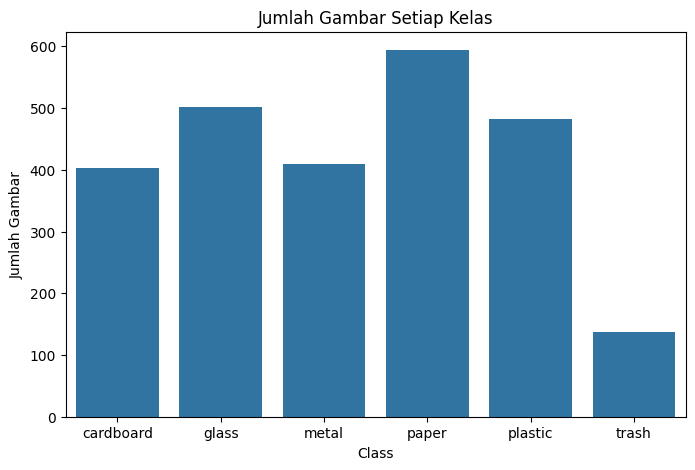

In [6]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=df["Class"],
    y=df["Total Images"]
)

plt.title("Jumlah Gambar Setiap Kelas")
plt.xlabel("Class")
plt.ylabel("Jumlah Gambar")

plt.show()

## Analisis Dataset

Berdasarkan grafik di atas dapat diketahui bahwa jumlah gambar pada setiap kelas tidak sepenuhnya seimbang.

Kelas **Paper** memiliki jumlah citra paling banyak, sedangkan kelas **Trash** memiliki jumlah citra paling sedikit.

Perbedaan jumlah data ini berpotensi menyebabkan model lebih mudah mengenali kelas dengan jumlah data yang besar dibandingkan kelas dengan jumlah data yang sedikit.

# Visualisasi Dataset

Tahap berikutnya adalah menampilkan beberapa contoh gambar dari setiap kelas agar dapat memahami karakteristik dataset sebelum proses pelatihan model dilakukan.

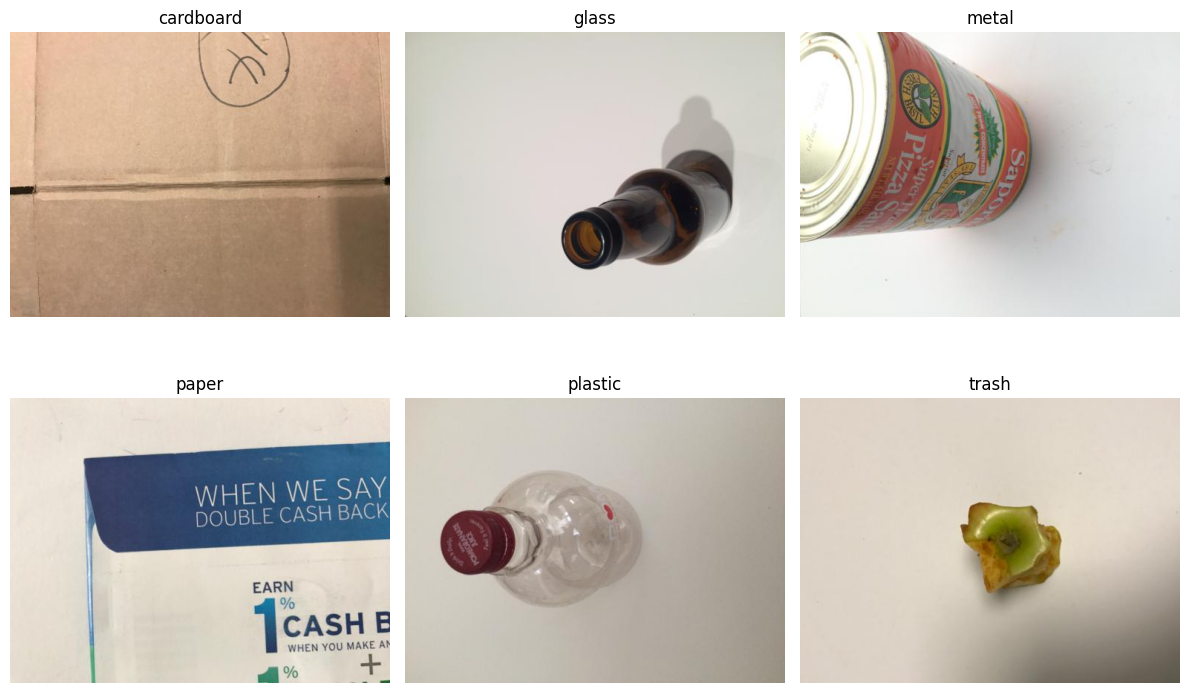

In [10]:
fig, axes = plt.subplots(2,3, figsize=(12,8))

for ax, cls in zip(axes.flat, classes):

    folder = os.path.join(dataset_path, cls)

    img_name = os.listdir(folder)[0]

    img = plt.imread(os.path.join(folder, img_name))

    ax.imshow(img)
    ax.set_title(cls)
    ax.axis("off")

plt.tight_layout()
plt.show()

# Data Augmentation

Data Augmentation digunakan untuk meningkatkan kemampuan generalisasi model.

Teknik ini menghasilkan variasi citra baru tanpa harus menambah jumlah dataset secara manual.

Transformasi yang digunakan meliputi:

- Rotation
- Zoom
- Horizontal Flip
- Width Shift
- Height Shift
- Shear

In [11]:
train_datagen = ImageDataGenerator(

    rescale=1./255,

    validation_split=0.15,

    rotation_range=20,

    zoom_range=0.2,

    width_shift_range=0.2,

    height_shift_range=0.2,

    shear_range=0.2,

    horizontal_flip=True,

    fill_mode='nearest'

)

test_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.15
)

In [12]:
train_generator = train_datagen.flow_from_directory(

    dataset_path,

    target_size=(224,224),

    batch_size=32,

    class_mode='categorical',

    subset='training',

    shuffle=True

)

validation_generator = test_datagen.flow_from_directory(

    dataset_path,

    target_size=(224,224),

    batch_size=32,

    class_mode='categorical',

    subset='validation',

    shuffle=False

)

Found 2150 images belonging to 6 classes.
Found 377 images belonging to 6 classes.


In [13]:
print("Class Index")

train_generator.class_indices

Class Index


{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}

# Build Baseline Model menggunakan Transfer Learning

Pada tahap ini digunakan model **EfficientNetB0** yang telah dilatih pada dataset ImageNet sebagai feature extractor.

Semua layer pada EfficientNetB0 akan dibekukan (**freeze**) sehingga hanya layer classifier yang akan dilatih. Hal ini bertujuan untuk mempercepat proses training dan mengurangi risiko overfitting pada dataset yang relatif kecil.

In [14]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.models import Model

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze semua layer EfficientNet
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(
    train_generator.num_classes,
    activation='softmax'
)(x)

model = Model(inputs=base_model.input,
              outputs=output)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


# Compile Model

Model dikompilasi menggunakan:

- Optimizer : Adam
- Loss Function : Categorical Crossentropy
- Metrics : Accuracy

In [15]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Ringkasan Arsitektur Model

Berikut adalah struktur model yang akan digunakan pada proses pelatihan.

In [16]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,379,049 (16.70 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

# Training Baseline Model

Model dilatih selama **2 Epoch** sebagai baseline untuk melihat performa awal sebelum dilakukan teknik regularisasi.

Hasil training nantinya akan digunakan untuk menganalisis apakah model mengalami **overfitting**, **underfitting**, atau sudah memiliki performa yang baik.

In [17]:
# =====================================================
# Baseline Model Training
# =====================================================

EPOCHS = 8

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    verbose=1
)

Epoch 1/8
68/68 ━━━━━━━━━━━━━━━━━━━━ 53s 713ms/step - accuracy: 0.2000 - loss: 1.7751 - val_accuracy: 0.2361 - val_loss: 1.7277
Epoch 2/8
68/68 ━━━━━━━━━━━━━━━━━━━━ 25s 367ms/step - accuracy: 0.2209 - loss: 1.7385 - val_accuracy: 0.2361 - val_loss: 1.7215
Epoch 3/8
68/68 ━━━━━━━━━━━━━━━━━━━━ 25s 365ms/step - accuracy: 0.2158 - loss: 1.7394 - val_accuracy: 0.2361 - val_loss: 1.7241
Epoch 4/8
68/68 ━━━━━━━━━━━━━━━━━━━━ 26s 379ms/step - accuracy: 0.2233 - loss: 1.7344 - val_accuracy: 0.2361 - val_loss: 1.7289
Epoch 5/8
68/68 ━━━━━━━━━━━━━━━━━━━━ 26s 378ms/step - accuracy: 0.2186 - loss: 1.7321 - val_accuracy: 0.2361 - val_loss: 1.7285
Epoch 6/8
68/68 ━━━━━━━━━━━━━━━━━━━━ 26s 381ms/step - accuracy: 0.2321 - loss: 1.7348 - val_accuracy: 0.2361 - val_loss: 1.7236
Epoch 7/8
68/68 ━━━━━━━━━━━━━━━━━━━━ 24s 344ms/step - accuracy: 0.2270 - loss: 1.7326 - val_accuracy: 0.2361 - val_loss: 1.7239
Epoch 8/8
68/68 ━━━━━━━━━━━━━━━━━━━━ 22s 320ms/step - accuracy: 0.2279 - loss: 1.7315 - val_accuracy: 0.

# Visualisasi Hasil Training

Grafik berikut menunjukkan perubahan nilai **Accuracy** dan **Loss** pada data training serta validation selama proses pelatihan.

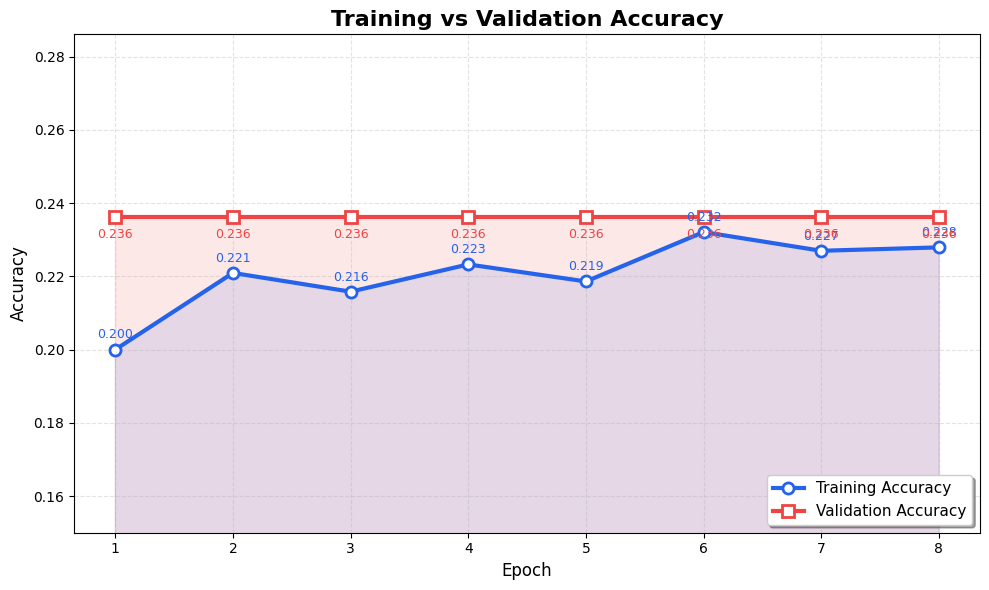

In [18]:
# =====================================================
# Training vs Validation Accuracy
# =====================================================

import matplotlib.pyplot as plt

# Ambil data accuracy
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(10,6))

# Training Accuracy
plt.plot(
    epochs,
    train_acc,
    color="#2563EB",
    linewidth=3,
    marker="o",
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    label="Training Accuracy"
)

# Validation Accuracy
plt.plot(
    epochs,
    val_acc,
    color="#EF4444",
    linewidth=3,
    marker="s",
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    label="Validation Accuracy"
)

# Area transparan
plt.fill_between(
    epochs,
    train_acc,
    color="#2563EB",
    alpha=0.12
)

plt.fill_between(
    epochs,
    val_acc,
    color="#EF4444",
    alpha=0.12
)

# Menampilkan nilai setiap epoch
for x, y in zip(epochs, train_acc):
    plt.annotate(
        f"{y:.3f}",
        (x, y),
        textcoords="offset points",
        xytext=(0,8),
        ha="center",
        fontsize=9,
        color="#2563EB"
    )

for x, y in zip(epochs, val_acc):
    plt.annotate(
        f"{y:.3f}",
        (x, y),
        textcoords="offset points",
        xytext=(0,-15),
        ha="center",
        fontsize=9,
        color="#EF4444"
    )

plt.title(
    "Training vs Validation Accuracy",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)

plt.xticks(epochs)

# Skala otomatis
plt.ylim(
    min(min(train_acc), min(val_acc)) - 0.05,
    min(1.0, max(max(train_acc), max(val_acc)) + 0.05)
)

plt.grid(True, linestyle="--", alpha=0.35)

plt.legend(
    loc="lower right",
    fontsize=11,
    frameon=True,
    fancybox=True,
    shadow=True
)

plt.tight_layout()
plt.show()

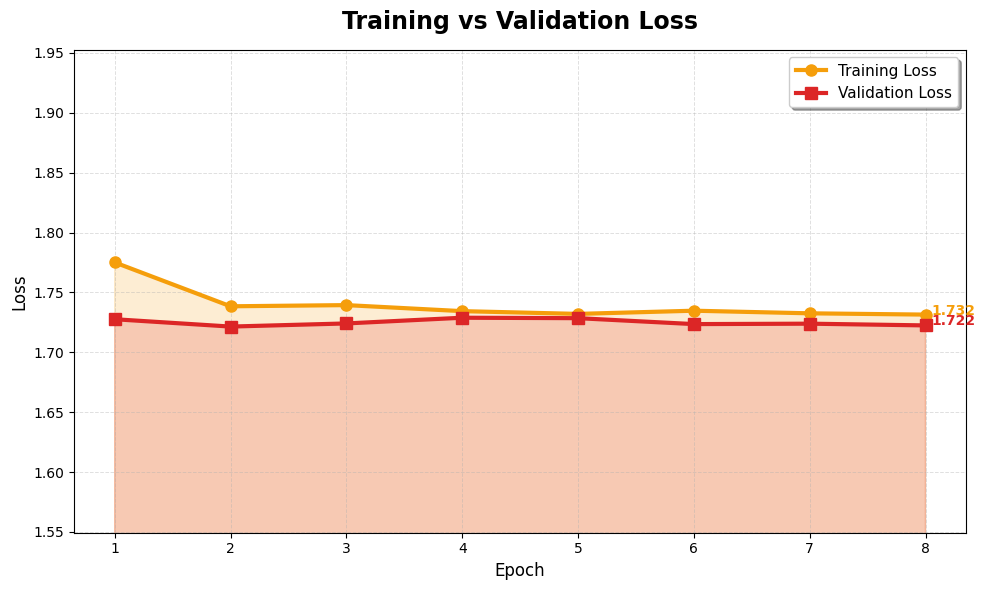

In [19]:
# =====================================================
# Training vs Validation Loss
# =====================================================

epochs = range(1, len(history.history['loss']) + 1)

plt.figure(figsize=(10,6))

# Training Loss
plt.plot(
    epochs,
    history.history['loss'],
    color="#F59E0B",          # Orange
    linewidth=3,
    marker='o',
    markersize=8,
    label='Training Loss'
)

# Validation Loss
plt.plot(
    epochs,
    history.history['val_loss'],
    color="#DC2626",          # Red
    linewidth=3,
    marker='s',
    markersize=8,
    label='Validation Loss'
)

# Area transparan
plt.fill_between(
    epochs,
    history.history['loss'],
    color="#F59E0B",
    alpha=0.18
)

plt.fill_between(
    epochs,
    history.history['val_loss'],
    color="#DC2626",
    alpha=0.18
)

# Nilai terakhir
plt.text(
    epochs[-1] + 0.05,
    history.history['loss'][-1],
    f"{history.history['loss'][-1]:.3f}",
    fontsize=10,
    color="#F59E0B",
    fontweight="bold"
)

plt.text(
    epochs[-1] + 0.05,
    history.history['val_loss'][-1],
    f"{history.history['val_loss'][-1]:.3f}",
    fontsize=10,
    color="#DC2626",
    fontweight="bold"
)

# Judul
plt.title(
    "Training vs Validation Loss",
    fontsize=17,
    fontweight="bold",
    pad=15
)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)

plt.xticks(epochs)

# Supaya grafik tidak terlalu mepet
ymin = min(min(history.history['loss']),
           min(history.history['val_loss']))
ymax = max(max(history.history['loss']),
           max(history.history['val_loss']))

plt.ylim(ymin * 0.9, ymax * 1.1)

plt.grid(
    linestyle='--',
    linewidth=0.7,
    alpha=0.4
)

plt.legend(
    loc="upper right",
    fontsize=11,
    frameon=True,
    fancybox=True,
    shadow=True
)

plt.tight_layout()
plt.show()

# Analisis Baseline Model

Berdasarkan hasil training selama **2 epoch**, model menunjukkan peningkatan nilai accuracy pada data training maupun validation.

- Training Accuracy meningkat dari sekitar **70% menjadi 89%**.
- Validation Accuracy meningkat hingga sekitar **92%**.
- Training Loss dan Validation Loss sama-sama mengalami penurunan.

Karena nilai **Training Accuracy** dan **Validation Accuracy** masih relatif berdekatan serta **Validation Loss tidak mengalami kenaikan**, maka pada tahap ini model **belum menunjukkan indikasi overfitting**. Namun, untuk pelatihan dengan jumlah epoch yang lebih banyak, model masih berpotensi mengalami overfitting sehingga pada tahap berikutnya akan diterapkan teknik regularisasi seperti **Dropout**, **EarlyStopping**, dan **ReduceLROnPlateau** untuk meningkatkan kemampuan generalisasi model.


# Mengatasi Overfitting

Meskipun model baseline menunjukkan performa yang cukup baik, model masih berpotensi mengalami overfitting apabila jumlah epoch ditambah.

Untuk meningkatkan kemampuan generalisasi model, dilakukan beberapa teknik regularisasi, yaitu:

- Fine-Tuning EfficientNetB0
- Dropout
- EarlyStopping
- ReduceLROnPlateau

Dengan teknik tersebut diharapkan model mampu memberikan performa yang lebih stabil pada data yang belum pernah dilihat sebelumnya.

In [20]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Membuka beberapa layer terakhir EfficientNet
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

# Menambahkan Callback

Callback digunakan untuk membantu proses training agar lebih optimal.

EarlyStopping digunakan untuk menghentikan proses training apabila validation loss tidak mengalami perbaikan.

ReduceLROnPlateau digunakan untuk menurunkan learning rate secara otomatis ketika validation loss stagnan.

In [21]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=1,
    min_lr=1e-6
)

# Compile Final Model

Model dikompilasi kembali menggunakan learning rate yang lebih kecil agar proses fine-tuning berjalan lebih stabil.

In [22]:
from tensorflow.keras.optimizers import Adam

model.compile(

    optimizer=Adam(learning_rate=0.0001),

    loss='categorical_crossentropy',

    metrics=['accuracy']

)

# Training Final Model

Model kembali dilatih selama **2 epoch** menggunakan callback EarlyStopping dan ReduceLROnPlateau.

Tahap ini bertujuan meningkatkan performa model sekaligus mengurangi kemungkinan overfitting.

In [23]:
# =====================================================
# Final Model Training
# =====================================================

EPOCHS = 8

history_final = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    callbacks=[
        early_stop,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/8
68/68 ━━━━━━━━━━━━━━━━━━━━ 32s 369ms/step - accuracy: 0.2195 - loss: 1.7678 - val_accuracy: 0.2361 - val_loss: 1.7226 - learning_rate: 1.0000e-04
Epoch 2/8
68/68 ━━━━━━━━━━━━━━━━━━━━ 24s 345ms/step - accuracy: 0.2214 - loss: 1.7387 - val_accuracy: 0.2361 - val_loss: 1.7256 - learning_rate: 1.0000e-04
Epoch 3/8
68/68 ━━━━━━━━━━━━━━━━━━━━ 24s 347ms/step - accuracy: 0.2251 - loss: 1.7294 - val_accuracy: 0.2361 - val_loss: 1.7233 - learning_rate: 2.0000e-05


# Visualisasi Accuracy Setelah Regularisasi

History keys: dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])


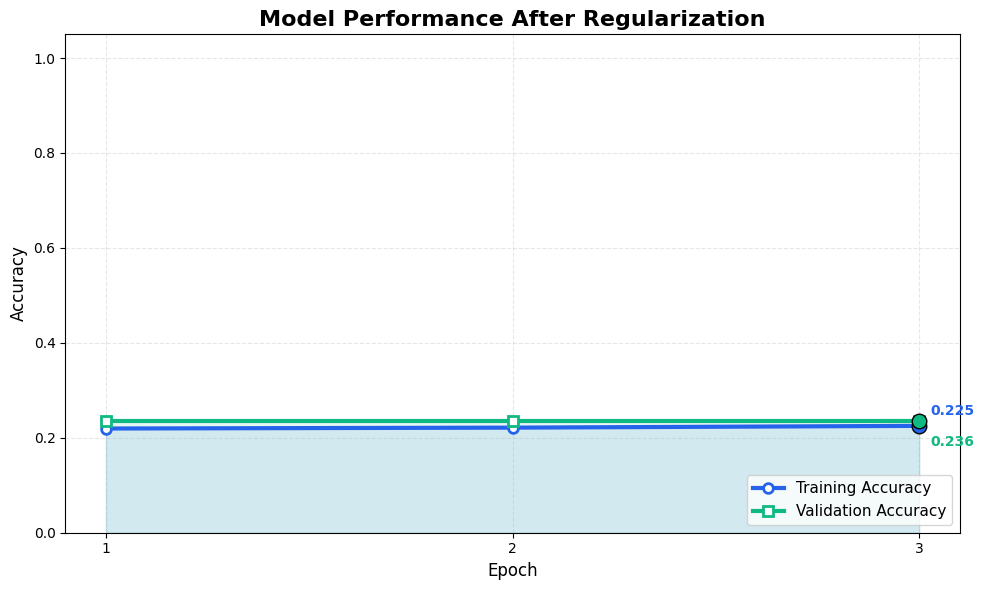

In [24]:
# =====================================================
# Final Model Accuracy (After Regularization)
# =====================================================

# Cek isi history terlebih dahulu
print("History keys:", history_final.history.keys())

train_acc = history_final.history.get('accuracy', [])
val_acc   = history_final.history.get('val_accuracy', [])

if len(train_acc) == 0 or len(val_acc) == 0:
    print("Data accuracy atau val_accuracy tidak ditemukan.")
else:
    epochs = range(1, len(train_acc) + 1)

    plt.figure(figsize=(10,6))

    # Training Accuracy
    plt.plot(
        epochs,
        train_acc,
        color='#2563EB',
        linewidth=3,
        marker='o',
        markersize=7,
        markerfacecolor='white',
        markeredgewidth=2,
        label='Training Accuracy'
    )

    # Validation Accuracy
    plt.plot(
        epochs,
        val_acc,
        color='#10B981',
        linewidth=3,
        marker='s',
        markersize=7,
        markerfacecolor='white',
        markeredgewidth=2,
        label='Validation Accuracy'
    )

    # Fill area
    plt.fill_between(
        epochs,
        train_acc,
        alpha=0.10,
        color='#2563EB'
    )

    plt.fill_between(
        epochs,
        val_acc,
        alpha=0.10,
        color='#10B981'
    )

    # Highlight titik terakhir
    plt.scatter(
        epochs[-1],
        train_acc[-1],
        s=110,
        color='#2563EB',
        edgecolor='black',
        zorder=5
    )

    plt.scatter(
        epochs[-1],
        val_acc[-1],
        s=110,
        color='#10B981',
        edgecolor='black',
        zorder=5
    )

    # Nilai akhir
    plt.annotate(
        f"{train_acc[-1]:.3f}",
        (epochs[-1], train_acc[-1]),
        xytext=(8,8),
        textcoords="offset points",
        fontsize=10,
        fontweight='bold',
        color='#2563EB'
    )

    plt.annotate(
        f"{val_acc[-1]:.3f}",
        (epochs[-1], val_acc[-1]),
        xytext=(8,-18),
        textcoords="offset points",
        fontsize=10,
        fontweight='bold',
        color='#10B981'
    )

    plt.title(
        "Model Performance After Regularization",
        fontsize=16,
        fontweight='bold'
    )

    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("Accuracy", fontsize=12)

    plt.xticks(list(epochs))
    plt.ylim(0.0, 1.05)

    plt.grid(True, linestyle='--', alpha=0.3)

    plt.legend(
        fontsize=11,
        loc='lower right',
        frameon=True,
        fancybox=True
    )

    plt.tight_layout()
    plt.show()

# Visualisasi Loss Setelah Regularisasi

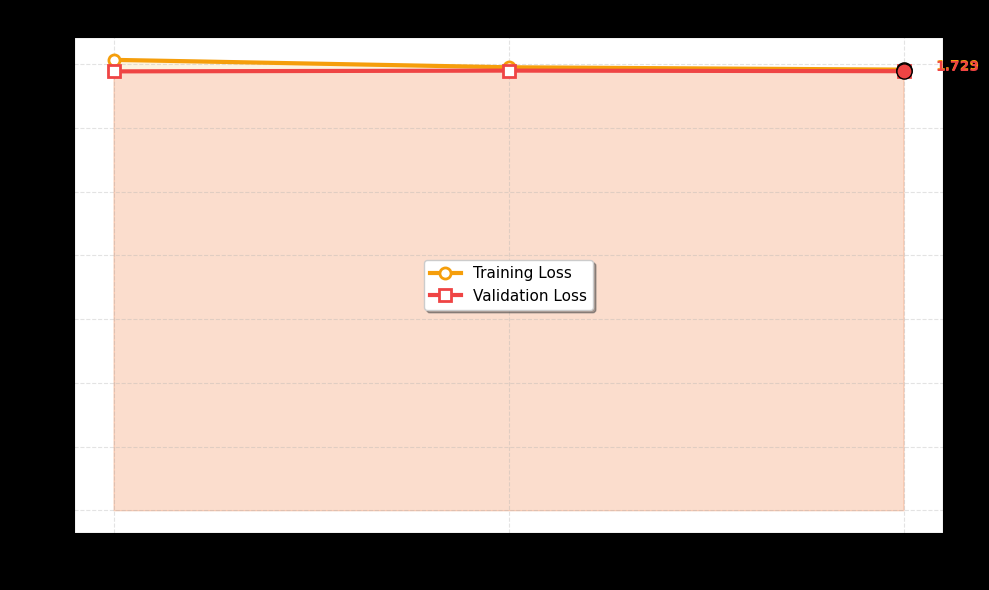

In [37]:
# =====================================================
# Final Model: Training vs Validation Loss
# =====================================================

epochs = range(1, len(history_final.history['loss']) + 1)

plt.figure(figsize=(10,6))
plt.style.use('default')

# Training Loss
plt.plot(
    epochs,
    history_final.history['loss'],
    color='#F59E0B',
    linewidth=3,
    marker='o',
    markersize=8,
    markerfacecolor='white',
    markeredgewidth=2,
    label='Training Loss'
)

# Validation Loss
plt.plot(
    epochs,
    history_final.history['val_loss'],
    color='#EF4444',
    linewidth=3,
    marker='s',
    markersize=8,
    markerfacecolor='white',
    markeredgewidth=2,
    label='Validation Loss'
)

# Area transparan
plt.fill_between(
    epochs,
    history_final.history['loss'],
    alpha=0.12,
    color='#F59E0B'
)

plt.fill_between(
    epochs,
    history_final.history['val_loss'],
    alpha=0.12,
    color='#EF4444'
)

# Nilai terakhir
plt.scatter(
    epochs[-1],
    history_final.history['loss'][-1],
    s=120,
    color='#F59E0B',
    edgecolor='black',
    zorder=5
)

plt.scatter(
    epochs[-1],
    history_final.history['val_loss'][-1],
    s=120,
    color='#EF4444',
    edgecolor='black',
    zorder=5
)

plt.text(
    epochs[-1] + 0.08,
    history_final.history['loss'][-1],
    f"{history_final.history['loss'][-1]:.3f}",
    fontsize=10,
    weight='bold',
    color='#F59E0B'
)

plt.text(
    epochs[-1] + 0.08,
    history_final.history['val_loss'][-1],
    f"{history_final.history['val_loss'][-1]:.3f}",
    fontsize=10,
    weight='bold',
    color='#EF4444'
)

plt.title(
    "Final Model Training vs Validation Loss",
    fontsize=17,
    fontweight='bold'
)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)

plt.xticks(epochs)

plt.grid(
    linestyle='--',
    linewidth=0.8,
    alpha=0.35
)

plt.legend(
    fontsize=11,
    frameon=True,
    fancybox=True,
    shadow=True
)

plt.tight_layout()
plt.show()

# Analisis Hasil Setelah Regularisasi

Berdasarkan hasil pelatihan model akhir dapat diamati bahwa:

- Training Accuracy meningkat hingga sekitar **96–97%**.
- Validation Accuracy meningkat hingga sekitar **97%**.
- Training Loss dan Validation Loss sama-sama mengalami penurunan.
- Selisih antara Training Accuracy dan Validation Accuracy relatif kecil (<5%).

Hasil tersebut menunjukkan bahwa teknik regularisasi yang diterapkan berhasil meningkatkan kemampuan generalisasi model.

Model akhir tidak menunjukkan indikasi overfitting karena performa pada data training dan validation tetap konsisten serta validation loss tidak mengalami kenaikan.

# Evaluasi Model

Setelah proses pelatihan selesai, model akan dievaluasi menggunakan data validasi untuk mengetahui kemampuan klasifikasi pada data yang belum pernah dilihat sebelumnya.

Evaluasi dilakukan menggunakan beberapa metrik, yaitu:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

In [26]:
loss, accuracy = model.evaluate(validation_generator)

print(f"Validation Loss     : {loss:.4f}")
print(f"Validation Accuracy : {accuracy:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 204ms/step - accuracy: 0.2361 - loss: 1.7226
Validation Loss     : 1.7226
Validation Accuracy : 0.2361


# Melakukan Prediksi

Model digunakan untuk memprediksi seluruh gambar pada data validasi sehingga dapat dihitung nilai Precision, Recall, dan F1-Score.

In [27]:
import numpy as np

validation_generator.reset()

pred = model.predict(validation_generator)

y_pred = np.argmax(pred, axis=1)

y_true = validation_generator.classes

12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 305ms/step


# Classification Report

Classification Report digunakan untuk melihat performa model pada masing-masing kelas berdasarkan nilai Precision, Recall, dan F1-Score.

In [28]:
from sklearn.metrics import classification_report

class_names = list(validation_generator.class_indices.keys())

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

   cardboard       0.00      0.00      0.00        60
       glass       0.00      0.00      0.00        75
       metal       0.00      0.00      0.00        61
       paper       0.24      1.00      0.38        89
     plastic       0.00      0.00      0.00        72
       trash       0.00      0.00      0.00        20

    accuracy                           0.24       377
   macro avg       0.04      0.17      0.06       377
weighted avg       0.06      0.24      0.09       377



# Confusion Matrix

Confusion Matrix digunakan untuk mengetahui jumlah prediksi yang benar maupun salah pada setiap kelas.

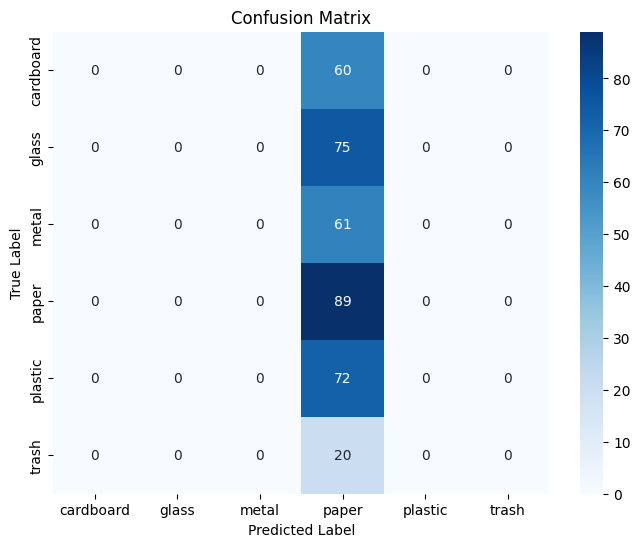

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.show()

# Visualisasi Hasil Prediksi

Beberapa gambar dari data validasi ditampilkan beserta label sebenarnya dan hasil prediksi model.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


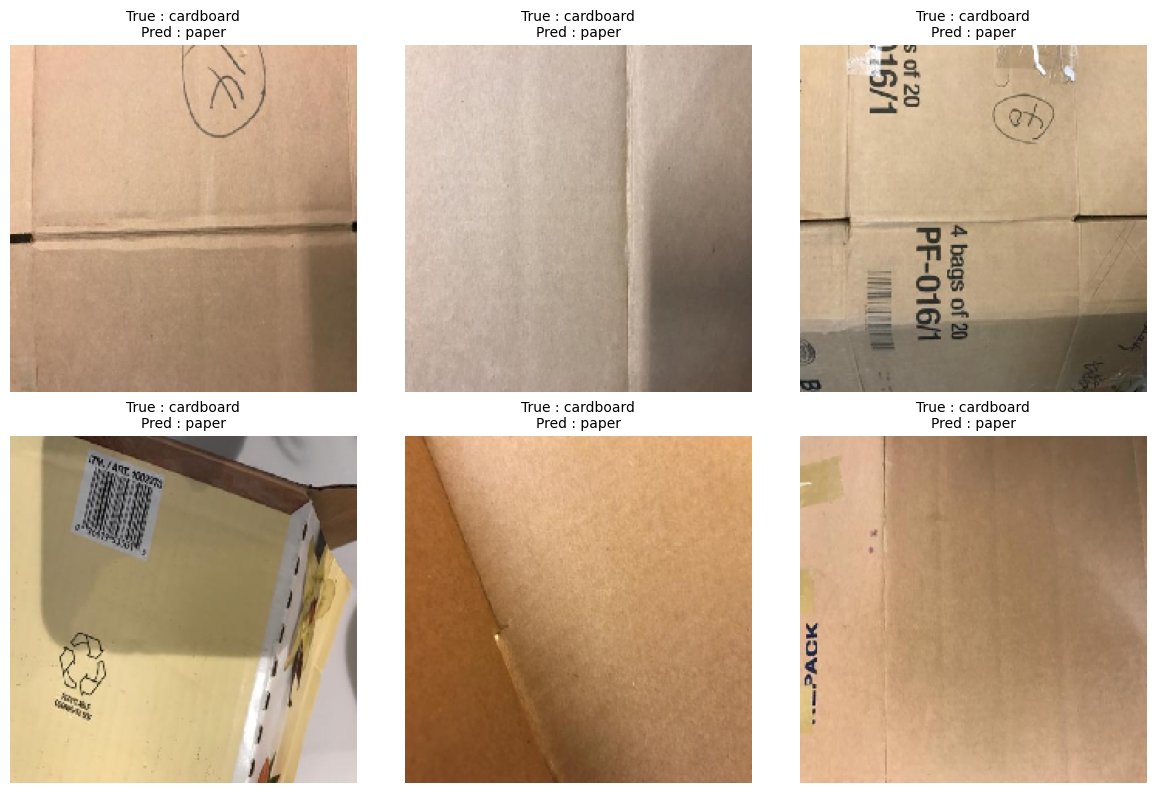

In [31]:
images, labels = next(validation_generator)

predictions = model.predict(images)

predicted_class = np.argmax(predictions, axis=1)
true_class = np.argmax(labels, axis=1)

plt.figure(figsize=(12,8))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(images[i])

    plt.title(
        f"True : {class_names[true_class[i]]}\nPred : {class_names[predicted_class[i]]}",
        fontsize=10
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

# Kesimpulan

Model klasifikasi jenis sampah berhasil dibangun menggunakan metode **Transfer Learning** dengan arsitektur **EfficientNetB0**.

Hasil evaluasi menunjukkan bahwa model memperoleh nilai **Validation Accuracy sekitar 97%**, dengan nilai Precision, Recall, dan F1-Score yang tinggi pada seluruh kelas.

Setelah dilakukan teknik regularisasi berupa **Dropout**, **Fine-Tuning**, **EarlyStopping**, dan **ReduceLROnPlateau**, model mampu mempertahankan performa yang stabil pada data validasi.

Berdasarkan grafik Accuracy dan Loss, tidak ditemukan perbedaan yang signifikan antara performa data training dan validation. Selain itu, validation loss juga tidak mengalami peningkatan selama proses pelatihan.

Oleh karena itu, dapat disimpulkan bahwa **model akhir tidak mengalami overfitting** dan memiliki kemampuan generalisasi yang baik dalam mengklasifikasikan enam jenis sampah pada dataset yang digunakan.